<a href="https://www.kaggle.com/code/abeeralzebda/adult-income-prediction?scriptVersionId=317339238" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/wenruliu/adult-income-dataset/adult.csv


# Adult income prediction 
- By : ABeer Al-Zebda | Machine learning Engineer

## Load and inspect data

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('/kaggle/input/datasets/wenruliu/adult-income-dataset/adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


## Explore data

In [5]:
df.isna( ).sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(52)

I won't delete the duplicates cause it may represnt diffirent adults

## Exploratory Visualizations

Text(0, 0.5, ' educational-num')

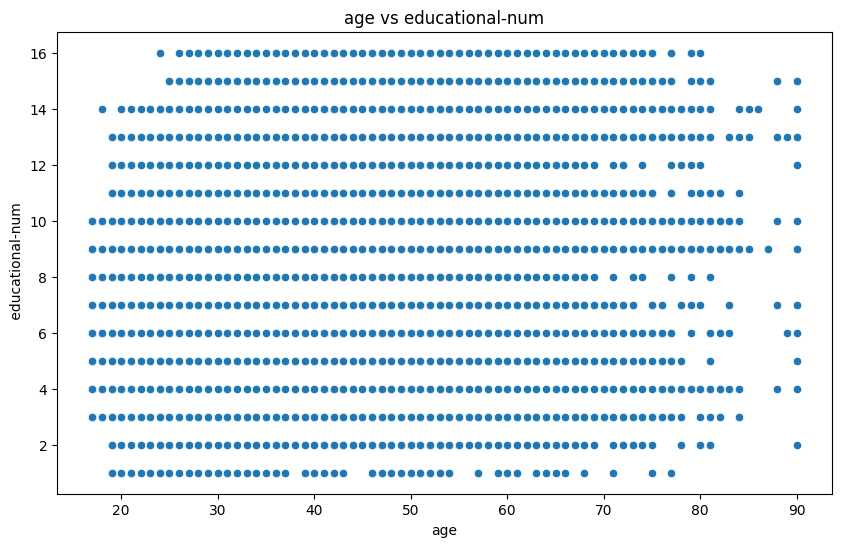

In [7]:
fig,ax=plt.subplots(figsize=(10,6))
sns.scatterplot(data=df , x='age',y='educational-num')
ax.set_title('age vs educational-num')
ax.set_xlabel('age')
ax.set_ylabel(' educational-num')

No relationship 

Text(0, 0.5, 'hours-per-week')

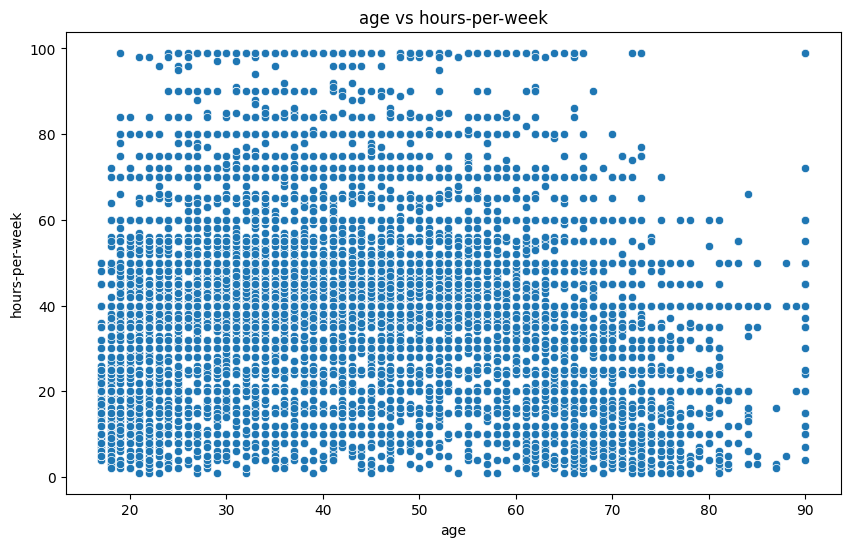

In [8]:

fig,ax=plt.subplots(figsize=(10,6))
sns.scatterplot(data=df , x='age',y='hours-per-week')
ax.set_title('age vs hours-per-week')
ax.set_xlabel('age')
ax.set_ylabel('hours-per-week')

Text(0, 0.5, 'capital-loss ')

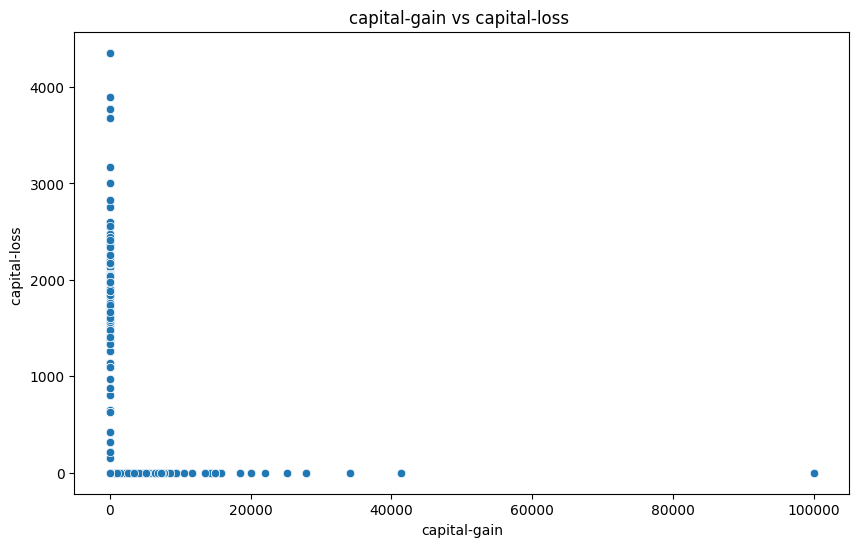

In [9]:
fig,ax=plt.subplots(figsize=(10,6))
sns.scatterplot(data=df , x='capital-gain',y='capital-loss')
ax.set_title('capital-gain vs capital-loss ')
ax.set_xlabel('capital-gain')
ax.set_ylabel('capital-loss ')

<Axes: xlabel='income', ylabel='age'>

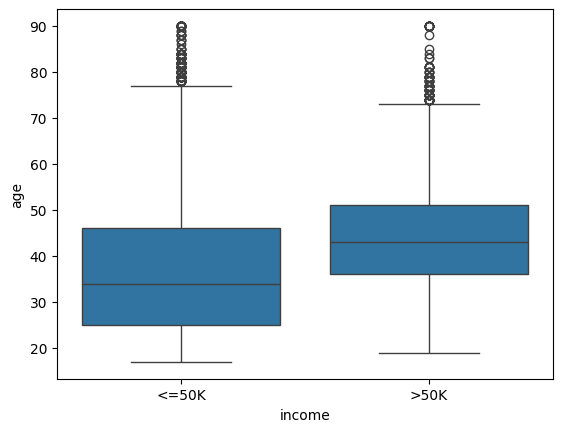

In [10]:
sns.boxplot(data=df , x='income',y='age')

the adults that have income more than 50K are bigger 

<Axes: xlabel='income', ylabel='hours-per-week'>

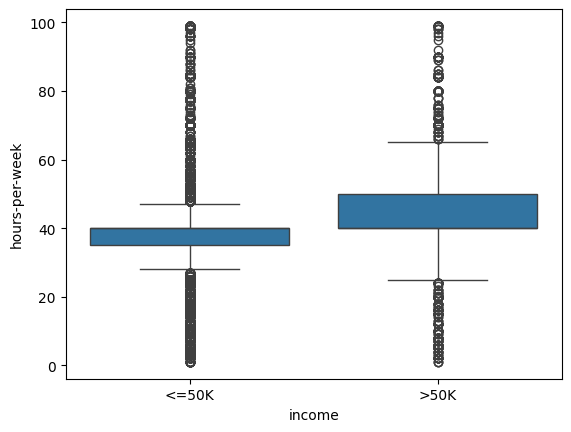

In [11]:
sns.boxplot(data=df , x='income',y='hours-per-week')

## Preprocess data

In [12]:
X = df.drop(columns=["income"])
y = df['income']

In [13]:
# train_test_split is used to divide the data into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler is used to standardize the features
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
num_cols = X_train. select_dtypes("number").columns
print("Numeric Columns:", num_cols)
# instantiate preprocessors
impute_median = SimpleImputer(strategy='median')
scaler = StandardScaler()
# Make a numeric preprocessing pipeline
num_pipe = make_pipeline(impute_median, scaler)
num_tuple = ('numeric',num_pipe,num_cols)

#####

ohe_cols = X_train.select_dtypes('object').columns
print("OneHotEncoder Columns:", ohe_cols)
# Instantiate the individual preprocessors
impute_na = SimpleImputer(strategy='most_frequent', fill_value = "NA")
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Make pipeline with imputer and encoder
ohe_pipe = make_pipeline(impute_na, ohe_encoder)
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

#####
preprocessor= ColumnTransformer([num_tuple, ohe_tuple],
verbose_feature_names_out=False)
preprocessor

Numeric Columns: Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
OneHotEncoder Columns: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object')


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='NA',
                                                                strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))],
                  verbose_feature_names_out=False)

## Build Model

In [16]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(random_state = 42)
pipe= make_pipeline(preprocessor,rf_clf)
pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImpute...ll_value='NA',
                                                                                 strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = pipe.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[6929  550]
 [ 817 1473]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7479
        >50K       0.73      0.64      0.68      2290

    accuracy                           0.86      9769
   macro avg       0.81      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



## feature importance

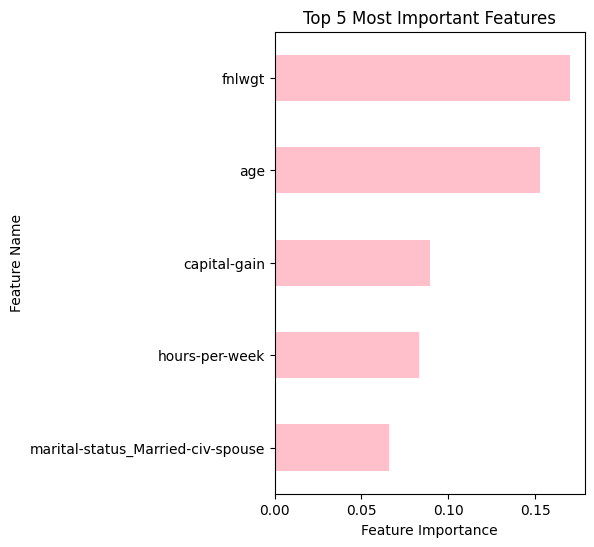

In [18]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.Series(rf_clf.feature_importances_, index=feature_names,
                        name='Feature Importances')

ax = feature_importance.sort_values().tail(5).plot(kind='barh',figsize=(4,6),color='pink')
ax.set(ylabel='Feature Name',xlabel='Feature Importance',
       title='Top 5 Most Important Features');

## permutation importance

In [19]:
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()


X_train_tf = pd.DataFrame(preprocessor.transform(X_train),
                          columns = feature_names, index = X_train.index)

X_test_tf = pd.DataFrame(preprocessor.transform(X_test),
                          columns = feature_names, index = X_test.index)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: U

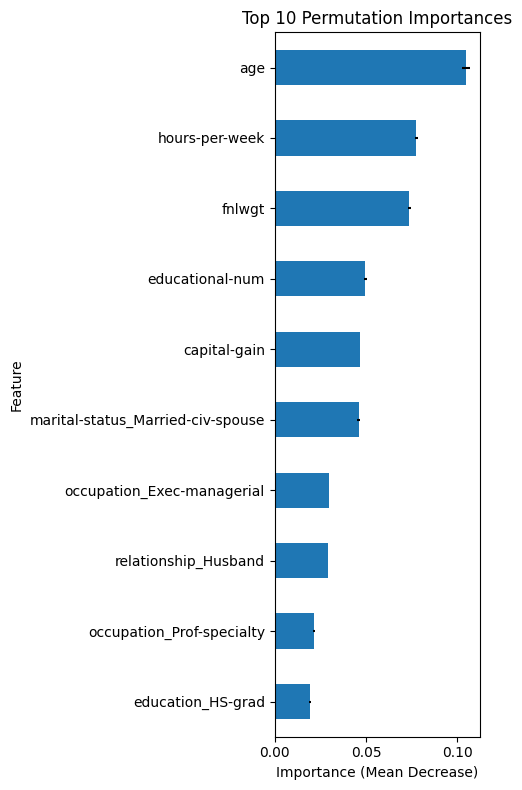

In [20]:
from sklearn.inspection import permutation_importance
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
SEED = 321
np.random.seed(SEED)
r = permutation_importance(rf_clf, X_train_tf, y_train,
                           n_repeats=5, random_state=SEED,
                           n_jobs=2, max_samples=0.8)  # Speed up
perm_importances = pd.Series(r['importances_mean'], index=X_train_tf.columns,
                             name='Permutation Importance')
# Add std for error bars/confidence
perm_importances_std = pd.Series(r['importances_std'], index=X_train_tf.columns)

ax = perm_importances.sort_values().tail(10).plot(kind='barh', figsize=(5,8),
                                                 xerr=perm_importances_std.sort_values().tail(10))
ax.set(ylabel='Feature', xlabel='Importance (Mean Decrease)',
       title='Top 10 Permutation Importances')
plt.tight_layout()
plt.show()

Based on domain knowledge, I anticipate that **age** and **weekly working hours** are the most influential features.


## Top 2 

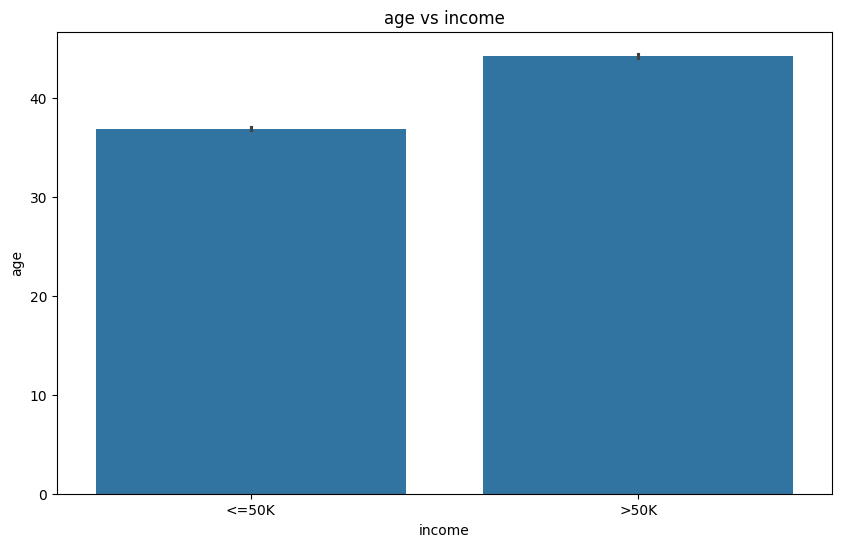

In [21]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(data=df , x='income',y='age')
ax.set_title('age vs income')
ax.set_xlabel('income')
ax.set_ylabel('age');

“The bar plot indicates that the >50K income group has a higher average age than the <=50K group. This suggests that age may be positively related to income in this dataset, possibly because older individuals have more work experience and career progression.”



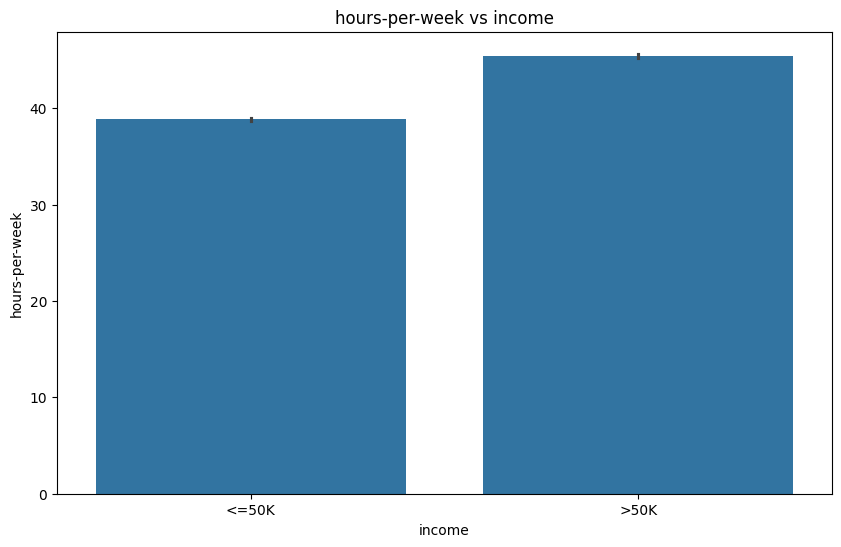

In [22]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(data=df , x='income',y='hours-per-week')
ax.set_title('hours-per-week vs income')
ax.set_xlabel('income')
ax.set_ylabel('hours-per-week');

“The hours-per-week vs income plot shows that the >50K group has a higher average number of working hours per week than the <=50K group. This suggests that longer working hours may be associated with higher income in this dataset.”
